In [34]:
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/Users/sanasalim/Downloads/Linkific/Day 6/synthetic_text_cleaning_realworld.csv")

In [4]:
df.sample(5)

,id,user_id,username,email,phone_number,tweet_text,post_text,comment_text,review_text,bio_text,...,product_description,advertisement_text,song_lyrics,movie_script,news_snippet,blog_text,story_text,job_description,company_profile,misc_text
1273,1274,RT @someone: This is a RETWEET with #hashtag,Café München is beautïful but costly $$$,Café München is beautïful but costly $$$,RT @someone: This is a RETWEET with #hashtag,123456789 Numbers should be removed!!!,Data cleaning is very IMPORTANT.....,Café München is beautïful but costly $$$,This TEXT has MULTIPLE spaces and --- dash...,Heeeyyy broooo wassuppp??? 😂😂😂,...,RT @someone: This is a RETWEET with #hashtag,Breaking news!!!! #AI #NLP @research,123456789 Numbers should be removed!!!,"Working on NLP??? It's fun, isn't it???",Data cleaning is very IMPORTANT.....,Check this out >>> https://openai.com,Hello!!! This is a SAMPLE text 😊.,123456789 Numbers should be removed!!!,Check this out >>> https://openai.com,Email me at test_user123@gmail.com asap!!!
264,265,<p>Python is GREAT!!!</p> Visit http://example...,This TEXT has MULTIPLE spaces and --- dash...,Download now >>> free link http://spam.com,Café München is beautïful but costly $$$,Check this out >>> https://openai.com,<p>Python is GREAT!!!</p> Visit http://example...,Café München is beautïful but costly $$$,U r the best!! btw I'll c u 2morrow 😉,This TEXT has MULTIPLE spaces and --- dash...,...,Café München is beautïful but costly $$$,Data cleaning is very IMPORTANT.....,<p>Python is GREAT!!!</p> Visit http://example...,Data cleaning is very IMPORTANT.....,This TEXT has MULTIPLE spaces and --- dash...,123456789 Numbers should be removed!!!,123456789 Numbers should be removed!!!,Check this out >>> https://openai.com,Café München is beautïful but costly $$$,Check this out >>> https://openai.com
370,371,Breaking news!!!! #AI #NLP @research,U r the best!! btw I'll c u 2morrow 😉,Data cleaning is very IMPORTANT.....,"Working on NLP??? It's fun, isn't it???",Data cleaning is very IMPORTANT.....,<p>Python is GREAT!!!</p> Visit http://example...,Data cleaning is very IMPORTANT.....,<p>Python is GREAT!!!</p> Visit http://example...,Breaking news!!!! #AI #NLP @research,...,Download now >>> free link http://spam.com,Café München is beautïful but costly $$$,123456789 Numbers should be removed!!!,U r the best!! btw I'll c u 2morrow 😉,RT @someone: This is a RETWEET with #hashtag,Stopwords should be removed from this text in ...,Data cleaning is very IMPORTANT.....,Breaking news!!!! #AI #NLP @research,Stopwords should be removed from this text in ...,Stopwords should be removed from this text in ...
1196,1197,123456789 Numbers should be removed!!!,RT @someone: This is a RETWEET with #hashtag,U r the best!! btw I'll c u 2morrow 😉,Café München is beautïful but costly $$$,Check this out >>> https://openai.com,Email me at test_user123@gmail.com asap!!!,U r the best!! btw I'll c u 2morrow 😉,Café München is beautïful but costly $$$,This TEXT has MULTIPLE spaces and --- dash...,...,Download now >>> free link http://spam.com,RT @someone: This is a RETWEET with #hashtag,Stopwords should be removed from this text in ...,Breaking news!!!! #AI #NLP @research,Breaking news!!!! #AI #NLP @research,RT @someone: This is a RETWEET with #hashtag,Stopwords should be removed from this text in ...,Check this out >>> https://openai.com,Check this out >>> https://openai.com,"Working on NLP??? It's fun, isn't it???"
646,647,U r the best!! btw I'll c u 2morrow 😉,U r the best!! btw I'll c u 2morrow 😉,Check this out >>> https://openai.com,Hello!!! This is a SAMPLE text 😊.,This TEXT has MULTIPLE spaces and --- dash...,Stopwords should be removed from this text in ...,Download now >>> free link http://spam.com,This TEXT has MULTIPLE spaces and --- dash...,Email me at test_user123@gmail.com asap!!!,...,Heeeyyy broooo wassuppp??? 😂😂😂,Stopwords should be removed from this text in ...,Email me at test_user123@gmail.com asap!!!,Download now >>> free link http://spam.com,Breaking

In [31]:
cleaned = df.copy()
'''
# remove numbers
cleaned["user_id"] = cleaned["user_id"].str.replace(r"\d","",regex=True)
# remove extra spaces
cleaned["user_id"] = cleaned["user_id"].str.replace(r"\s+"," ",regex=True)
# remove special characters 
cleaned["user_id"] = cleaned["user_id"].str.replace(r"\W"," ",regex=True)
cleaned.head()
'''

columns = cleaned.select_dtypes(include=['object']).columns
for col in columns:
    cleaned[col] = cleaned[col].str.replace(r'\d', ' ', regex=True).str.strip()
    cleaned[col] = cleaned[col].str.replace(r'\s+', ' ', regex=True)
    cleaned[col] = cleaned[col].str.replace(r'\W|[_]', ' ', regex=True).str.strip()

cleaned.head()

,id,user_id,username,email,phone_number,tweet_text,post_text,comment_text,review_text,bio_text,...,product_description,advertisement_text,song_lyrics,movie_script,news_snippet,blog_text,story_text,job_description,company_profile,misc_text
0,1,Download now free link http spam com,Data cleaning is very IMPORTANT,Check this out https openai com,U r the best btw I ll c u morrow,Data cleaning is very IMPORTANT,Email me at test user gmail com asap,U r the best btw I ll c u morrow,Café München is beautïful but costly,Download now free link http spam com,...,Heeeyyy broooo wassuppp,Breaking news AI NLP research,Café München is beautïful but costly,Download now free link http spam com,RT someone This is a RETWEET with hashtag,Breaking news AI NLP research,Download now free link http spam com,Café München is beautïful but costly,Breaking news AI NLP research,Download now free link http spam com
1,2,Stopwords should be removed from this text in ...,Check this out https openai com,Email me at test user gmail com asap,Working on NLP It s fun isn t it,Café München is beautïful but costly,Heeeyyy broooo wassuppp,Heeeyyy broooo wassuppp,Numbers should be removed,Café München is beautïful but costly,...,Café München is beautïful but costly,Numbers should be removed,This TEXT has MULTIPLE spaces and dashes,U r the best btw I ll c u morrow,Email me at test user gmail com asap,Check this out https openai com,U r the best btw I ll c u morrow,Check this out https openai com,Numbers should be removed,p Python is GREAT p Visit http example ...
2,3,Heeeyyy broooo wassuppp,Stopwords should be removed from this text in ...,Email me at test user gmail com asap,Café München is beautïful but costly,Breaking news AI NLP research,Email me at test user gmail com asap,Data cleaning is very IMPORTANT,Check this out https openai com,Hello This is a SAMPLE text,...,Breaking news AI NLP research,Working on NLP It s fun isn t it,U r the best btw I ll c u morrow,This TEXT has MULTIPLE spaces and dashes,RT someone This is a RETWEET with hashtag,Download now free link http spam com,Stopwords should be removed from this text in ...,Hello This is a SAMPLE text,Numbers should be removed,Numbers should be removed
3,4,Café München is beautïful but costly,Data cleaning is very IMPORTANT,U r the best btw I ll c u morrow,Stopwords should be removed from this text in ...,U r the best btw I ll c u morrow,Data cleaning is very IMPORTANT,Data cleaning is very IMPORTANT,This TEXT has MULTIPLE spaces and dashes,Email me at test user gmail com asap,...,Breaking news AI NLP research,Stopwords should be removed from this text in ...,This TEXT has MULTIPLE spaces and dashes,p Python is GREAT p Visit http example ...,Café München is beautïful but costly,Café München is beautïful but costly,Breaking news AI NLP research,Numbers should be removed,Email me at test user gmail com asap,Download now free link http spam com
4,5,This TEXT has MULTIPLE spaces and dashes,This TEXT has MULTIPLE spaces and dashes,Check this out https openai com,Working on NLP It s fun isn t it,Numbers should be removed,Hello This is a SAMPLE text,U r the best btw I ll c u morrow,U r the best btw I ll c u morrow,Heeeyyy broooo wassuppp,...,Email me at test user gmail com asap,This TEXT has MULTIPLE spaces and dashes,Check this out https openai com,Hello This is a SAMPLE text,Check this out https openai com,Café München is beautïful but costly,Check this out https openai com,Heeeyyy broooo wassuppp,U r the best btw I ll c u morrow,Café München is beautïful but costly


In [32]:
cleaned.sample(5)

,id,user_id,username,email,phone_number,tweet_text,post_text,comment_text,review_text,bio_text,...,product_description,advertisement_text,song_lyrics,movie_script,news_snippet,blog_text,story_text,job_description,company_profile,misc_text
1559,1560,RT someone This is a RETWEET with hashtag,This TEXT has MULTIPLE spaces and dashes,This TEXT has MULTIPLE spaces and dashes,U r the best btw I ll c u morrow,Data cleaning is very IMPORTANT,Working on NLP It s fun isn t it,p Python is GREAT p Visit http example ...,Check this out https openai com,Stopwords should be removed from this text in ...,...,Email me at test user gmail com asap,Download now free link http spam com,Heeeyyy broooo wassuppp,This TEXT has MULTIPLE spaces and dashes,Numbers should be removed,Breaking news AI NLP research,Numbers should be removed,Email me at test user gmail com asap,Heeeyyy broooo wassuppp,Working on NLP It s fun isn t it
1311,1312,Stopwords should be removed from this text in ...,Data cleaning is very IMPORTANT,Check this out https openai com,This TEXT has MULTIPLE spaces and dashes,Heeeyyy broooo wassuppp,Working on NLP It s fun isn t it,RT someone This is a RETWEET with hashtag,Hello This is a SAMPLE text,Working on NLP It s fun isn t it,...,Email me at test user gmail com asap,Numbers should be removed,Numbers should be removed,Breaking news AI NLP research,Hello This is a SAMPLE text,Breaking news AI NLP research,This TEXT has MULTIPLE spaces and dashes,This TEXT has MULTIPLE spaces and dashes,Breaking news AI NLP research,This TEXT has MULTIPLE spaces and dashes
1564,1565,Working on NLP It s fun isn t it,Working on NLP It s fun isn t it,p Python is GREAT p Visit http example ...,Café München is beautïful but costly,Café München is beautïful but costly,Numbers should be removed,Heeeyyy broooo wassuppp,Café München is beautïful but costly,RT someone This is a RETWEET with hashtag,...,U r the best btw I ll c u morrow,Check this out https openai com,Stopwords should be removed from this text in ...,Numbers should be removed,Stopwords should be removed from this text in ...,p Python is GREAT p Visit http example ...,Café München is beautïful but costly,Hello This is a SAMPLE text,Café München is beautïful but costly,This TEXT has MULTIPLE spaces and dashes
463,464,This TEXT has MULTIPLE spaces and dashes,Check this out https openai com,Stopwords should be removed from this text in ...,Stopwords should be removed from this text in ...,Hello This is a SAMPLE text,Café München is beautïful but costly,Hello This is a SAMPLE text,Download now free link http spam com,Check this out https openai com,...,Download now free link http spam com,Numbers should be removed,Working on NLP It s fun isn t it,Heeeyyy broooo wassuppp,This TEXT has MULTIPLE spaces and dashes,RT someone This is a RETWEET with hashtag,Email me at test user gmail com asap,RT someone This is a RETWEET with hashtag,Email me at test user gmail com asap,Hello This is a SAMPLE text
1615,1616,This TEXT has MULTIPLE spaces and dashes,RT someone This is a RETWEET with hashtag,This TEXT has MULTIPLE spaces and dashes,Numbers should be removed,Stopwords should be removed from this text in ...,Working on NLP It s fun isn t it,Email me at test user gmail com asap,Breaking news AI NLP research,Numbers should be removed,...,Working on NLP It s fun isn t it,Download now free link http spam com,This TEXT has MULTIPLE spaces and dashes,Hello This is a SAMPLE text,Check this out https openai com,Download now free link http spam com,Hello This is a SAMPLE text,U r the best btw I ll c u morrow,RT someone This is a RETWEET with hashtag,Stopwords should be removed from this text in ...


### Visualisation

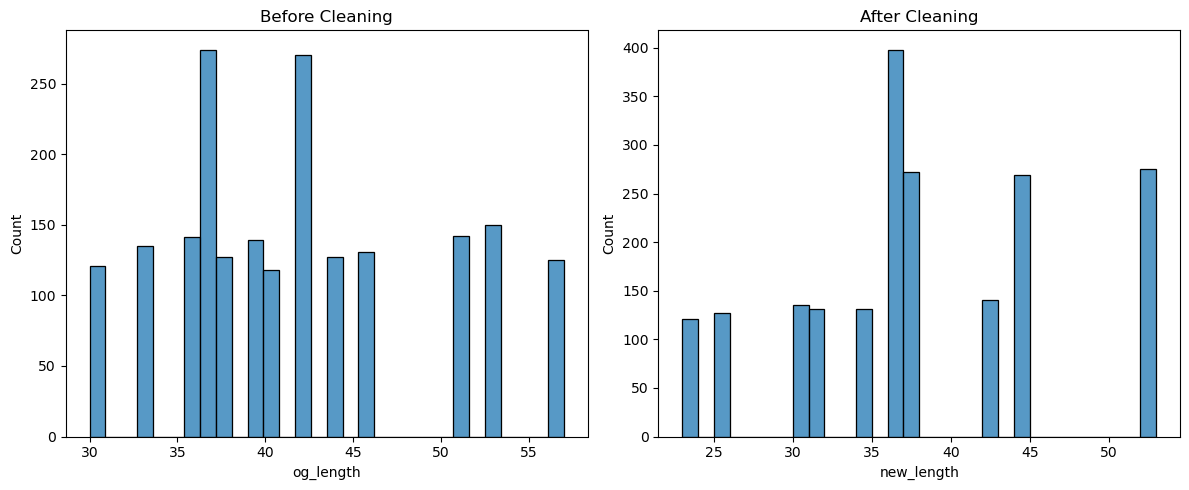

In [38]:
df["og_length"] = df["user_id"].astype(str).str.len()
cleaned["new_length"] = cleaned["user_id"].astype(str).str.len()
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.histplot(df["og_length"],bins=30,ax=axes[0])
axes[0].set_title("Before Cleaning")
sns.histplot(cleaned["new_length"],bins=30,ax=axes[1])
axes[1].set_title("After Cleaning")
plt.tight_layout()
plt.show()

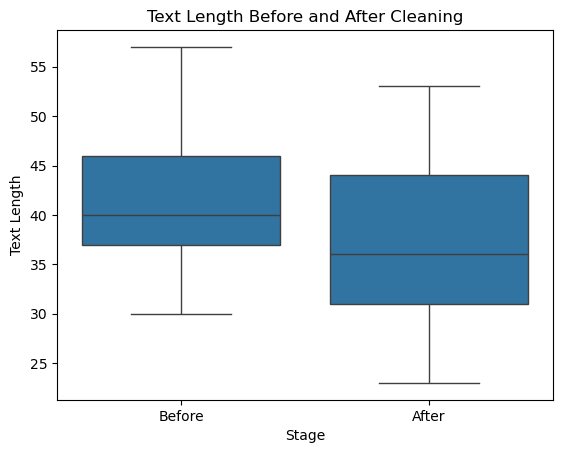

In [46]:
# create new dataframe to compare before and after
plot_df = pd.DataFrame({"Text Length": pd.concat([df["og_length"],cleaned["new_length"]]),"Stage": (["Before"]*len(cleaned)+["After"]*len(cleaned))})
sns.boxplot(data=plot_df,x="Stage",y="Text Length")

plt.title("Text Length Before and After Cleaning")
plt.show()
